# Milestone 2 Notebook
Authors: Kshitij Sharma, Elouann Lucas

## Milestone 1 summary - dataset preparation and exploration

Dataset collection is done in the [preprocess](preprocess.ipynb) notebook.

Previous feature engineering and extraction is done in the [stats computation](stats_computation.ipynb) notebook.

### New steps conducted after Milestone 1
After the feedback received during Milestone 1, we made the following changes to our dataset preparation process:
1.  Reduced the amount of categories by merging them using the level 2 [corine land cover legend](../docs/CLC_Legend_EN.pdf) (from level 3), which gives us a total of 10 classes instead of 24. This selection is also done during the running of the main pipeline as it simplifies the process.
2.  Cleaned polygons by merging the multi-polygons corresponding to the same sample into one polygon.
3.  Performed further data analysis to better understand the distribution of raster values for each class.
4.  Extracted features from the rasters and polygons (this stepped cannot be reproduced locally as the rasters are not stored locally due to their size).

### 1. Reducing categories
To reduce the number of categories, we mapped the level 3 classes to level 2 classes as per the [corine land cover legend](../docs/CLC_Legend_EN.pdf).

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 
import os

In [22]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
gdf = gpd.read_file(data_path)

In [23]:
print(gdf['CODIGO'].value_counts())

CODIGO
0       683
231     322
311     158
333     145
112     142
233     128
232      64
313      59
22       57
21       42
122      34
511      23
312      18
111      17
512      14
323      14
3212     13
32       10
331       6
334       4
121       4
3211      3
513       3
31        1
Name: count, dtype: int64


<Axes: xlabel='CODIGO_GROUP_2'>

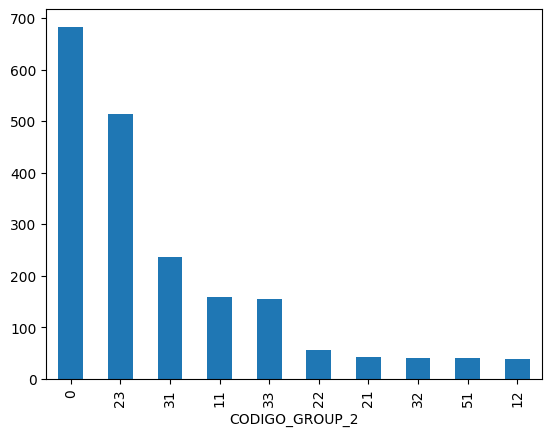

In [24]:
gdf['CODIGO_GROUP_2'] = gdf['CODIGO'].astype(str).str[:2]
gdf['CODIGO_GROUP_2'].value_counts().plot(kind='bar')

#### Mapping to level 1

We also mapped to level 1 classes, which will be used for comparison later. There are 5 level 1 classes in total.

<Axes: xlabel='CODIGO_GROUP_1'>

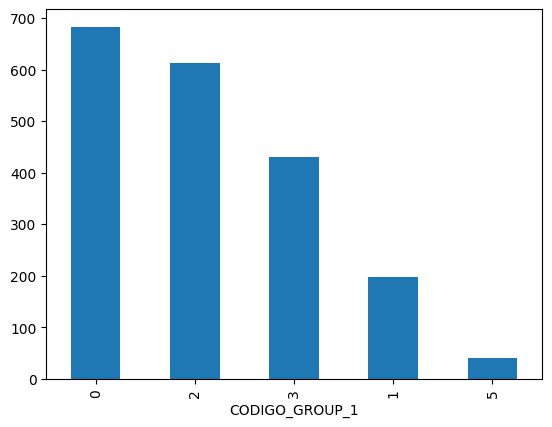

In [25]:
gdf['CODIGO_GROUP_1'] = gdf['CODIGO'].astype(str).str[:1]
gdf['CODIGO_GROUP_1'].value_counts().plot(kind='bar')

In [26]:
print(gdf['CODIGO_GROUP_2'].value_counts())

CODIGO_GROUP_2
0     683
23    514
31    236
11    159
33    155
22     57
21     42
32     40
51     40
12     38
Name: count, dtype: int64


### 2. Checking and cleaning multi-polygons

We first count the number of polygons in a geometry object:
if the geometry is a MultiPolygon, it returns the number of individual polygons it contains.
if the geometry is a Polygon, it returns 1.

In [27]:
def count_polygons(geometry):
    if geometry.geom_type == 'MultiPolygon':
        return len(list(geometry.geoms))
    elif geometry.geom_type == 'Polygon':
        return 1
    else:
        return 0

gdf['n_polygons'] = gdf['geometry'].apply(count_polygons)

display(gdf.head())

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,perimeter,compactness,shape_index,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,geometry,CODIGO_GROUP_2,CODIGO_GROUP_1,n_polygons
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,35863.728720,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1331.480192,0.254212,1.983362,0.900242,0.437163,0.817446,"POLYGON ((-72.97056 10.61903, -72.97054 10.619...",23,2,1
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,7067.391800,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,445.486569,0.447507,1.494859,1.759124,0.730754,0.714141,"POLYGON ((-72.96914 10.61884, -72.96915 10.618...",21,2,1
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12736.830326,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,514.273064,0.605179,1.285459,1.150156,0.535901,0.780932,"POLYGON ((-72.96928 10.61948, -72.96931 10.619...",11,1,1
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,20192.843054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,578.345347,0.758635,1.148110,1.465598,0.735386,0.693349,"POLYGON ((-72.97264 10.61976, -72.97273 10.619...",23,2,1
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5222.807786,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,459.390754,0.310992,1.793186,1.024244,0.401829,0.845566,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204...",31,3,1


In [28]:
gdf['n_polygons'].value_counts()

n_polygons
1    1964
Name: count, dtype: int64

In [29]:
exploded_gdf = gdf.explode(ignore_index=True)

exploded_gdf['n_polygons'] = exploded_gdf['geometry'].apply(count_polygons)

exploded_gdf['poly_id'] = exploded_gdf.reset_index().index

display(exploded_gdf.head())

display(exploded_gdf['n_polygons'].value_counts())

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,perimeter,compactness,shape_index,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,CODIGO_GROUP_2,CODIGO_GROUP_1,n_polygons,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,35863.728720,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1331.480192,0.254212,1.983362,0.900242,0.437163,0.817446,23,2,1,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,7067.391800,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,445.486569,0.447507,1.494859,1.759124,0.730754,0.714141,21,2,1,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12736.830326,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,514.273064,0.605179,1.285459,1.150156,0.535901,0.780932,11,1,1,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,20192.843054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,578.345347,0.758635,1.148110,1.465598,0.735386,0.693349,23,2,1,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5222.807786,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,459.390754,0.310992,1.793186,1.024244,0.401829,0.845566,31,3,1,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."


n_polygons
1    1964
Name: count, dtype: int64

In [30]:
exploded_gdf.drop(columns=['n_polygons'], inplace=True)

In [31]:
exploded_gdf.drop_duplicates(subset='geometry', inplace=True)

In [32]:
exploded_gdf

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,mean_intensity,perimeter,compactness,shape_index,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,CODIGO_GROUP_2,CODIGO_GROUP_1,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,35863.728720,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,63.165356,1331.480192,0.254212,1.983362,0.900242,0.437163,0.817446,23,2,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,7067.391800,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,75.517822,445.486569,0.447507,1.494859,1.759124,0.730754,0.714141,21,2,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12736.830326,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,57.324478,514.273064,0.605179,1.285459,1.150156,0.535901,0.780932,11,1,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,20192.843054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,93.691475,578.345347,0.758635,1.148110,1.465598,0.735386,0.693349,23,2,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5222.807786,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,32.228394,459.390754,0.310992,1.793186,1.024244,0.401829,0.845566,31,3,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1545.971923,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,28.864557,242.379949,0.330688,1.738965,0.838901,0.354046,0.859828,23,2,"POLYGON ((-75.123 3.80901, -75.12297 3.809, -7..."
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026303,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.083861,11.946954,0.002316,20.780311,0.823263,0.044593,0.996933,33,3,"POLYGON ((-75.12391 3.81075, -75.1239 3.81076,..."
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10654.442452,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,27.726738,1277.998650,0.081975,3.492690,1.323494,0.527732,0.798940,23,2,"POLYGON ((-75.12278 3.8104, -75.12282 3.81044,..."
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5196.479151,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,44.873081,376.043545,0.461788,1.471562,1.437832,0.682919,0.724081,23,2,"POLYGON ((-75.12367 3.81079, -75.12357 3.81077..."


In [33]:
invalid_polygons = exploded_gdf[~exploded_gdf.geometry.is_valid]
print(len(invalid_polygons))

16


In [34]:
exploded_gdf['geometry'] = exploded_gdf.geometry.make_valid()

In [35]:
invalid_polygons = exploded_gdf[~exploded_gdf.geometry.is_valid]
print(len(invalid_polygons))

0


In [36]:
exploded_gdf.dropna(subset=['OBSERV'])

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,mean_intensity,perimeter,compactness,shape_index,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,CODIGO_GROUP_2,CODIGO_GROUP_1,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,35863.728720,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,63.165356,1331.480192,0.254212,1.983362,0.900242,0.437163,0.817446,23,2,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,7067.391800,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,75.517822,445.486569,0.447507,1.494859,1.759124,0.730754,0.714141,21,2,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12736.830326,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,57.324478,514.273064,0.605179,1.285459,1.150156,0.535901,0.780932,11,1,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,20192.843054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,93.691475,578.345347,0.758635,1.148110,1.465598,0.735386,0.693349,23,2,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5222.807786,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,32.228394,459.390754,0.310992,1.793186,1.024244,0.401829,0.845566,31,3,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1545.971923,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,28.864557,242.379949,0.330688,1.738965,0.838901,0.354046,0.859828,23,2,"POLYGON ((-75.123 3.80901, -75.12297 3.809, -7..."
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026303,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,0.083861,11.946954,0.002316,20.780311,0.823263,0.044593,0.996933,33,3,"POLYGON ((-75.12391 3.81075, -75.1239 3.81076,..."
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10654.442452,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,27.726738,1277.998650,0.081975,3.492690,1.323494,0.527732,0.798940,23,2,"POLYGON ((-75.12282 3.81044, -75.12284 3.81048..."
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5196.479151,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,44.873081,376.043545,0.461788,1.471562,1.437832,0.682919,0.724081,23,2,"POLYGON ((-75.12367 3.81079, -75.12357 3.81077..."


In [37]:
exploded_gdf.to_file('polygon_cleaned.geojson', driver='GeoJSON')

### 3.1. Raster value analysis

Since the analysis is performed on raster files, these functions only work when the data is downloaded locally.

In [38]:
# with rasterio.open(cog_url) as src:

#     r_band = src.read(1)
#     g_band = src.read(2)
#     b_band = src.read(3)

#     is_masked = np.ma.isMaskedArray(r_band)
    
#     if is_masked:
#         valid_mask = ~(r_band.mask | g_band.mask | b_band.mask)
#     else:
#         nodata = src.nodata if src.nodata is not None else -9999
#         valid_mask = (r_band != nodata) & (g_band != nodata) & (b_band != nodata) & (r_band != 0) & (g_band != 0) & (b_band != 0)
    
#     r_valid = r_band[valid_mask]
#     g_valid = g_band[valid_mask]
#     b_valid = b_band[valid_mask]

#     band_data = [r_valid, g_valid, b_valid]
#     band_labels = ['Red Band', 'Green Band', 'Blue Band']
#     band_colors = ['red', 'green', 'blue']
    
#     plt.figure(figsize=(8, 6))
    
#     bp = plt.boxplot(band_data, 
#                      tick_labels=band_labels, 
#                      patch_artist=True,
#                      medianprops={'color': 'black'})
    
#     for box, color in zip(bp['boxes'], band_colors):
#         box.set_facecolor(color)
#         box.set_alpha(0.6)
    
#     plt.title('Box Plot of RGB Band Pixel Values (Full raster)')
#     plt.ylabel('Pixel Value')
#     plt.xlabel('Band')
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.tight_layout()

In [39]:
# def extract_valid_data(src, row, gdf_crs):
    
#     geom_gdf = gpd.GeoDataFrame([row], geometry='geometry', crs=gdf_crs)
#     geom_reprojected = geom_gdf.to_crs(src.crs)
#     geom_transformed = [geom_reprojected.geometry.iloc[0].__geo_interface__]
    
#     masked_data, _ = mask(src, geom_transformed, crop=True, all_touched=False)
#     r_band, g_band, b_band = masked_data[0], masked_data[1], masked_data[2]

#     nodata = src.nodata if src.nodata is not None else -9999
#     valid_mask = np.ones(r_band.shape, dtype=bool)
    
#     if np.ma.isMaskedArray(r_band):
#         valid_mask = ~(r_band.mask | g_band.mask | b_band.mask)
#     else:
#         valid_mask &= (r_band != nodata) & (g_band != nodata) & (b_band != nodata)
        
#     valid_mask &= (r_band != 0) & (g_band != 0) & (b_band != 0)

#     r_valid = r_band[valid_mask].astype(float)
#     g_valid = g_band[valid_mask].astype(float)
#     b_valid = b_band[valid_mask].astype(float)

#     return [r_valid, g_valid, b_valid]


# row_1 = gdf.iloc[85]
# row_2 = gdf.iloc[124]
# cog_url = f"{base_url}/{'img_0004_befb8cbc'}.tif" # Use the image_uid from the first row

# band_labels = ['Red', 'Green', 'Blue']
# band_colors = ['red', 'green', 'blue']

# with rasterio.open(cog_url) as src:
#         data_1 = extract_valid_data(src, row_1, gdf.crs)
#         data_2 = extract_valid_data(src, row_2, gdf.crs)


# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# titles = [f"AOI {row_1.OBSERV}", f"AOI {row_2.OBSERV}"]
# datasets = [data_1, data_2]

# for ax, data, title in zip(axes, datasets, titles):
    
#     if any(arr.size > 0 for arr in data):
#         bp = ax.boxplot(data, 
#                          labels=band_labels, 
#                          patch_artist=True,
#                          medianprops={'color': 'black'})
        
#         # Apply colors to boxes
#         for box, color in zip(bp['boxes'], band_colors):
#             box.set_facecolor(color)
#             box.set_alpha(0.6)
            
#         ax.set_title(title, fontsize=14)
#         ax.set_ylabel('Pixel Value')
#         ax.set_xlabel('Band')
#         ax.grid(axis='y', linestyle='--', alpha=0.7)
#     else:
#         ax.set_title(f"{title} (No Valid Data Found)", fontsize=14)
#         ax.axis('off')

# fig.suptitle(f"RGB Band Pixel Value Comparison from Raster: {row_1['image_uid']}", fontsize=16)
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig('two_aoi_box_plots_comparison.png')

Analysis of rasters pixel values reveals that some classes show specific spectral signature.
However, some spectral signatures are similar between classes, which may lead to misclassifications later on.

### 3.2. Feature Analysis

In [40]:
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'train_files.geojson')

train_gdf = gpd.read_file(data_path)
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std']

print("Feature Statistics:")
print(train_gdf[features].describe())

Feature Statistics:
            r_mean     r_median        r_std        r_var       g_mean  \
count  1543.000000  1543.000000  1543.000000  1543.000000  1543.000000   
mean    127.487788   130.171095    44.380365  2178.014820   133.975828   
std      42.473480    50.314825    14.440677  1408.881370    38.013409   
min      14.052425     9.000000     9.624962    92.639891    16.971166   
25%      94.908565    91.000000    33.558212  1126.153600   108.241590   
50%     121.510849   121.000000    42.470746  1803.764262   128.770921   
75%     154.023560   160.000000    53.579690  2870.783253   155.508736   
max     244.339260   255.000000    90.384147  8169.294104   246.924832   

          g_median        g_std        g_var       b_mean     b_median  \
count  1543.000000  1543.000000  1543.000000  1543.000000  1543.000000   
mean    137.039209    41.252715  1897.912498   104.649876   105.043746   
std      44.930367    14.009039  1305.675024    50.340175    59.719284   
min      11.00000

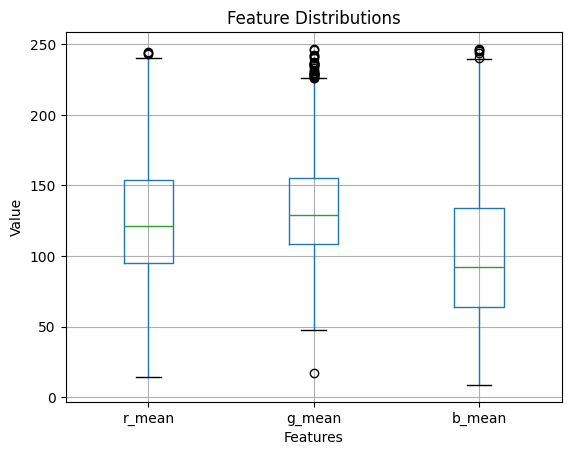

In [41]:
display_features = ['r_mean','g_mean','b_mean']

train_gdf[display_features].boxplot()
plt.title('Feature Distributions')
plt.ylabel('Value')
plt.xlabel('Features')
plt.show()

On this box plot showing the distribution of `r_mean`, `g_mean`, and `b_mean` values, we can observe that the dataset tends towards lower blue mean values, indicating that the rasters in our dataset have less blue reflectance. This could be due to the prevalence of vegetation and soil, which typically reflect more in the red and green bands.

To get more insights, we will later see how these features correlate with each other

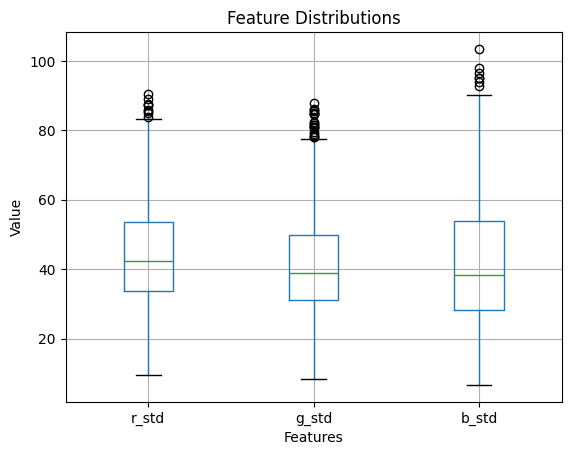

In [42]:
display_features = ['r_std','g_std','b_std']

train_gdf[display_features].boxplot()
plt.title('Feature Distributions')
plt.ylabel('Value')
plt.xlabel('Features')
plt.show()

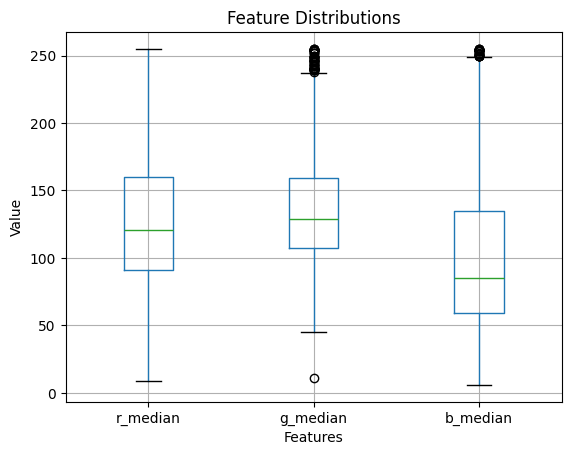

In [43]:
display_features = ['r_median','g_median','b_median']

train_gdf[display_features].boxplot()
plt.title('Feature Distributions')
plt.ylabel('Value')
plt.xlabel('Features')
plt.show()

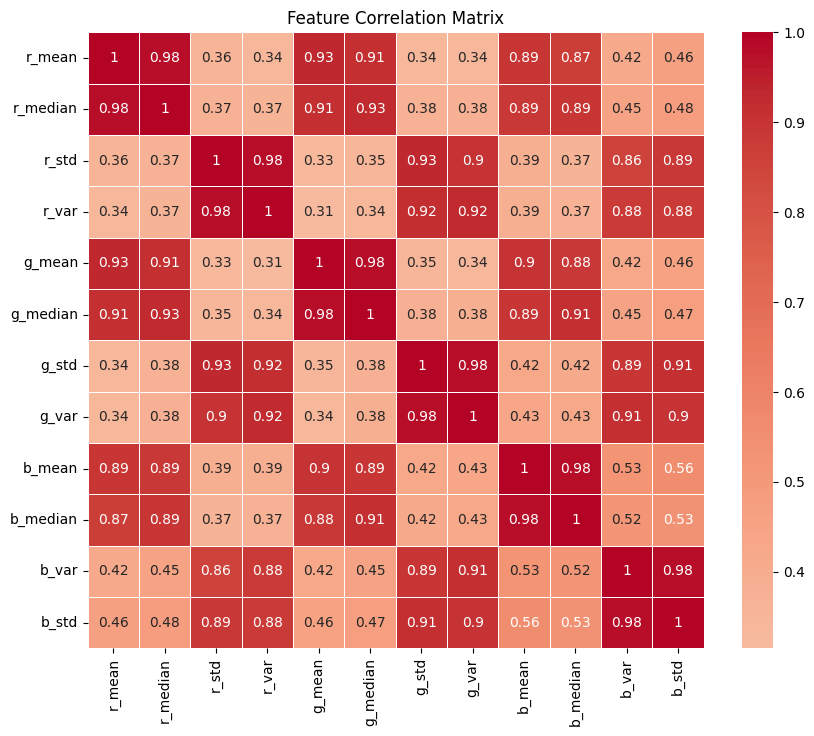

In [44]:
plt.figure(figsize=(10, 8))
correlation_matrix = train_gdf[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

Here the correlation between `r_mean` and `g_mean` is very high : almost identical , similar to `r_mean` and `b_mean` . All RGB bands are highly redundant , they don't provide much value, however, the `area` contains extremely crucial information as it is calculated from geometric properties instead of optical.

### 4. New features extracted

We have extracted new features based on the feedback received during Milestone 1. These features include both image-based features and texture-based features, which can provide additional information for land cover classification.
Buidling upon the previous features, we have added the following:

Image features:
- eccentricity
- solidity
- mean_intensity
- perimeter
- compactness
- shape_index
- area

Texture features:
- glcm_contrast
- glcm_dissimilarity
- glcm_homogeneity

Since the feature extraction is performed on raster files, these functions only work when the data is downloaded locally.

In [45]:
# from tqdm import tqdm
# from skimage.measure import regionprops, label
# import numpy as np 
# import rasterio 
# from rasterio.mask import mask

# big_polygons = 0 

# def compute_regionprops(gdf, image_uid_col='image_uid', base_url='/home/krschap/Jupyter/ubs/ml/mlproject1/landcoverclassification/data/images/cog'):
#     for col in ['eccentricity', 'solidity', 'mean_intensity']:
#         gdf[col] = np.nan
    
#     for idx, row in tqdm(gdf.iterrows(), total=len(gdf), desc="Regionprops"):
#             try : 
#                 with rasterio.open(f"{base_url}/{row[image_uid_col]}.tif") as src:
#                     geom = gpd.GeoDataFrame([row], geometry='geometry', crs=gdf.crs).to_crs(src.crs)
#                     masked, _ = mask(src, [geom.geometry.iloc[0].__geo_interface__], crop=True, all_touched=False)
                    
#                     # if masked[0].size > 10_000_000 * 3:
#                     #     big_polygons=+1
#                     #     print('big polygon detected') 
                        
#                     #     continue
                    
#                     valid = ~masked[0].mask if np.ma.isMaskedArray(masked[0]) else masked[0] != (src.nodata or -9999)
#                     labeled = label(valid.astype(np.uint8))
                    
#                     if labeled.max() > 0:
#                         intensity = (masked[0].astype(np.float32) + masked[1].astype(np.float32) + masked[2].astype(np.float32)) / 3.0
#                         region = regionprops(labeled, intensity_image=intensity)[0] # source : https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
#                         gdf.at[idx, 'eccentricity'] = region.eccentricity
#                         gdf.at[idx, 'solidity'] = region.solidity
#                         gdf.at[idx, 'mean_intensity'] = region.mean_intensity 
                    
#                     del masked, valid, labeled, intensity, region
#             except :
#                 pass

#     return gdf

In [46]:
# import sys, os 
# import geopandas as gpd 
# sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
# data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
# gdf = gpd.read_file(data_path)

In [47]:
# gdf_stats = compute_regionprops(gdf)

In [48]:
# gdf_stats['area'] = gdf_stats.to_crs(3857).geometry.area

# gdf_stats["perimeter"] = gdf_stats.to_crs(3857).geometry.length

# gdf_stats["compactness"] = (4 * np.pi * gdf_stats["area"]) / (gdf_stats["perimeter"] ** 2)
# gdf_stats["shape_index"] = gdf_stats["perimeter"] / (2 * np.sqrt(np.pi * gdf_stats["area"])) # source : https://www.fs.usda.gov/pnw/pubs/pnw_gtr351.pdf  

In [49]:
#   gdf_stats.to_file(os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson'))

## Milestone 2 - Model training and evaluation

In [50]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os 
import sys 
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint
import matplotlib.pyplot as plt
from boruta import BorutaPy

In [51]:
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson')
gdf = gpd.read_file(data_path)

In [52]:
class Runner:
    """Class to run machine learning experiments with Random Forest and SVM classifiers on geospatial data."""
    def __init__(self, gdf, target_column, features, test_size=0.2, random_state=42):
        """Initializes the Runner with the given GeoDataFrame and parameters.

        Args:
            gdf (geopandas.GeoDataFrame): The input GeoDataFrame containing features and target.
            target_column (str): The name of the target column in the GeoDataFrame.
            features (list): List of feature column names to be used for training.
            test_size (float, optional): Proportion of the dataset to include in the test split. Defaults to 0.2.
            random_state (int, optional): Random seed for reproducibility. Defaults to 42.
        """
        self.gdf = gdf
        self.target_column = target_column
        self.features = features
        self.test_size = test_size
        self.random_state = random_state
        self.label_map = self._get_label_map()
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.labels = None
        self.results = {}
        self.models = {}
        self.feature_map = {}
        
    def _get_label_map(self):
        """Returns the label mapping based on the target column.

        Returns:
            dict: A dictionary mapping class codes to human-readable labels.
        """
        if self.target_column == 'CODIGO_GROUP_2':
            return {'0':'Building','11':'Urban','12':'Highway','21':'Seasonal crops','22':'Permanent crops',
                    '23':'Pasture','31':'Forest','32':'Grassland','33':'Bare areas','51':'Water'}
        return {'0':'Building','1':'Artificial Surfaces','2':'Agriculture','3':'Forest','4':'Wetlands','5':'Water'}
        
    def load_train_test_data(self):
        """Splits the GeoDataFrame into training and testing sets, and prepares the feature matrices and target vectors.
        """
        train_gdf, test_gdf = train_test_split(self.gdf, test_size=self.test_size, 
                                                random_state=self.random_state, 
                                                stratify=self.gdf[self.target_column])
        train_gdf['OBSERV_GROUP'] = train_gdf[self.target_column].replace(self.label_map)
        test_gdf['OBSERV_GROUP'] = test_gdf[self.target_column].replace(self.label_map)
        
        self.X_train = train_gdf[self.features]
        self.y_train = train_gdf['OBSERV_GROUP']
        self.X_test = test_gdf[self.features]
        self.y_test = test_gdf['OBSERV_GROUP']
        self.labels = train_gdf['OBSERV_GROUP'].unique()
        
        print("train distribution:")
        print(train_gdf['OBSERV_GROUP'].value_counts())
        print("\ntest distribution:")
        print(test_gdf['OBSERV_GROUP'].value_counts())
        
    def _rf_hyperparameter_tuning(self, X_train, y_train, use_smote=False):
        """Performs hyperparameter tuning for Random Forest Classifier using RandomizedSearchCV with optional SMOTE."""
        param_dist = {
            'clf__n_estimators': randint(50, 300),
            'clf__max_depth': [2, 9, 12, 15, 20, None],
            'clf__max_leaf_nodes': [None], 
            'clf__min_samples_leaf': randint(1, 10),
            'clf__min_samples_split': randint(2, 15),
            'clf__class_weight': ['balanced','balanced_subsample'], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
        } # https://www.geeksforgeeks.org/machine-learning/how-to-solve-overfitting-in-random-forest-in-python-sklearn/ 
        
        # StratifiedKFold to maintain class distribution in folds during cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        steps = []
        if use_smote:
            steps.append(('smote', SMOTE(sampling_strategy='minority', random_state=self.random_state)))
        steps.append(('clf', RandomForestClassifier(random_state=self.random_state)))
        pipe = ImbPipeline(steps)
        
        # https://medium.com/@aditib259/a-comprehensive-guide-to-hyperparameter-tuning-in-machine-learning-dd9bb8072d02 
        search = RandomizedSearchCV(pipe, param_dist, n_iter=30, cv=cv, n_jobs=-1, 
                                verbose=1, scoring='f1_macro', return_train_score=True,
                                random_state=self.random_state) # tries 30 random iterations
        search.fit(X_train, y_train)
        return search
    def _svm_hyperparameter_tuning(self, X_train, y_train, use_smote=False):
        """Performs hyperparameter tuning for SVM Classifier using RandomizedSearchCV with optional SMOTE."""
        param_dist = {
            'clf__C': randint(1, 10),
            'clf__class_weight': [None, 'balanced'],
            'clf__gamma': ['scale', 'auto'],
            'clf__kernel': ['rbf', 'poly', 'sigmoid']
        }
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        # StandardScaler is important for SVM performance since our features have different scales
        steps = [('scaler', StandardScaler())]
        if use_smote:
            steps.append(('smote', SMOTE(sampling_strategy='minority', random_state=self.random_state)))
        steps.append(('clf', SVC(random_state=self.random_state)))
        pipe = ImbPipeline(steps)
        
        search = RandomizedSearchCV(pipe, param_dist, cv=cv, n_jobs=-1, verbose=0,
                                    scoring='f1_macro', return_train_score=True, 
                                    random_state=self.random_state)
        search.fit(X_train, y_train)
        return search
    
    def _compute_accuracy(self, model, X_test, y_test, name=''):
        """Computes accuracy metrics and plots confusion matrices for the given model and test data."""
        y_pred = model.predict(X_test)
        ac_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=1) # zero_division=1 to handle any zero division cases
        
        cm = confusion_matrix(y_test, y_pred, labels=self.labels)
        cm_norm = confusion_matrix(y_test, y_pred, labels=self.labels, normalize='true')
        
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
        ConfusionMatrixDisplay(cm, display_labels=self.labels).plot(ax=ax[0], cmap=plt.cm.Blues, 
                                                                     colorbar=False, xticks_rotation=90)
        ConfusionMatrixDisplay(cm_norm, display_labels=self.labels).plot(ax=ax[1], cmap=plt.cm.Blues, 
                                                                          colorbar=False, xticks_rotation=90)
        ax[0].set_title(f'{name} CM')
        ax[1].set_title(f'{name} Norm CM')
        plt.show()
        
        print("Best params:", model.best_params_)
        print("Val f1:", model.cv_results_['mean_test_score'][model.best_index_])
        print("Train f1:", model.cv_results_['mean_train_score'][model.best_index_])
        return ac_dict
    
    def run_rf_normal(self):
        """Runs Random Forest Classifier without any sampling technique."""
        print("\nRF Normal")
        model = self._rf_hyperparameter_tuning(self.X_train, self.y_train, use_smote=False)
        ac_dict = self._compute_accuracy(model, self.X_test, self.y_test, 'RF Normal')
        
        self.results['RF Normal'] = {
            'train_score': model.cv_results_['mean_train_score'][model.best_index_],
            'val_score': model.cv_results_['mean_test_score'][model.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['RF Normal'] = model.best_estimator_
        self.feature_map['RF Normal'] = self.features
        print(f"Test f1: {self.results['RF Normal']['test_score']:.4f}")
        
    def run_rf_with_smote(self, custom_features=None):
        """Runs Random Forest Classifier with SMOTE sampling technique."""
        key = 'RF SMOTE (Boruta)' if custom_features else 'RF SMOTE'
        print(f"\n{key}")
        
        X_tr = self.X_train[custom_features] if custom_features else self.X_train
        X_te = self.X_test[custom_features] if custom_features else self.X_test
        
        model = self._rf_hyperparameter_tuning(X_tr, self.y_train, use_smote=True)
        ac_dict = self._compute_accuracy(model, X_te, self.y_test, key)
        
        self.results[key] = {
            'train_score': model.cv_results_['mean_train_score'][model.best_index_],
            'val_score': model.cv_results_['mean_test_score'][model.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models[key] = model.best_estimator_
        self.feature_map[key] = custom_features if custom_features else self.features
        print(f"Test f1: {self.results[key]['test_score']:.4f}")
        
    def run_rf_with_rus(self):
        """Runs Random Forest Classifier with Random Under Sampling (RUS) technique."""
        print("\nRF RUS")
        rus = RandomUnderSampler(random_state=self.random_state)
        X_res, y_res = rus.fit_resample(self.X_train, self.y_train)
        model = self._rf_hyperparameter_tuning(X_res, y_res, use_smote=False)
        ac_dict = self._compute_accuracy(model, self.X_test, self.y_test, 'RF RUS')
        
        self.results['RF RUS'] = {
            'train_score': model.cv_results_['mean_train_score'][model.best_index_],
            'val_score': model.cv_results_['mean_test_score'][model.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['RF RUS'] = model.best_estimator_
        self.feature_map['RF RUS'] = self.features
        
    def run_svm_normal(self):
        """Runs SVM Classifier without any sampling technique."""
        print("\nSVM Normal")
        model = self._svm_hyperparameter_tuning(self.X_train, self.y_train, use_smote=False)
        ac_dict = self._compute_accuracy(model, self.X_test, self.y_test, 'SVM Normal')
        
        self.results['SVM Normal'] = {
            'train_score': model.cv_results_['mean_train_score'][model.best_index_],
            'val_score': model.cv_results_['mean_test_score'][model.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['SVM Normal'] = model.best_estimator_
        print(f"Test f1: {self.results['SVM Normal']['test_score']:.4f}")
        
    def run_svm_with_smote(self):
        """"Runs SVM Classifier with SMOTE sampling technique."""
        print("\nSVM SMOTE")
        model = self._svm_hyperparameter_tuning(self.X_train, self.y_train, use_smote=True)
        ac_dict = self._compute_accuracy(model, self.X_test, self.y_test, 'SVM SMOTE')
        
        self.results['SVM SMOTE'] = {
            'train_score': model.cv_results_['mean_train_score'][model.best_index_],
            'val_score': model.cv_results_['mean_test_score'][model.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['SVM SMOTE'] = model.best_estimator_
        print(f"Test f1: {self.results['SVM SMOTE']['test_score']:.4f}")
        
    def get_dummy_f1_scores(self):
        """Computes F1 scores for various Dummy Classifier strategies."""
        for strategy in ['most_frequent', 'stratified', 'uniform']:
            dummy = DummyClassifier(strategy=strategy, random_state=self.random_state)
            dummy.fit(self.X_train, self.y_train)
            y_pred = dummy.predict(self.X_test)
            report = classification_report(self.y_test, y_pred, output_dict=True, zero_division=1)
            
            self.results[f'Dummy ({strategy})'] = {
                'train_score': 0, 'val_score': 0,
                'test_score': report['macro avg']['f1-score']
            }
    
    def run_boruta_feature_selection(self, base_model_key='RF Normal'):
        """Runs Boruta feature selection using the specified base model."""
        print("\nBoruta")
        if base_model_key not in self.models:
            print(f"{base_model_key} not found")
            return None
        
        base = self.models[base_model_key]
        clf = base.named_steps.get('clf', base)
        boruta = BorutaPy(clf, n_estimators='auto', verbose=0, random_state=self.random_state)
        boruta.fit(self.X_train.values, self.y_train.values) # source : audrey & https://towardsdatascience.com/feature-selection-with-boruta-in-python-676e3877e596/
        
        selected = [f for f, s in zip(self.features, boruta.support_) if s]
        print(f"Selected: {len(selected)}/{len(self.features)}")
        print(f"Removed: {set(self.features) - set(selected)}")
        return selected
    

    def plot_comparison(self):
        """Plots a comparison of train, validation, and test F1 scores for all models."""
        items = list(self.results.items())
        names = [n for n, _ in items]
        train = [s['train_score'] for _, s in items]
        val = [s['val_score'] for _, s in items]
        test = [s['test_score'] for _, s in items]
        
        x = np.arange(len(names))
        w = 0.25
        
        fig, ax = plt.subplots(figsize=(14, 7))
        bars1 = ax.bar(x - w, train, w, label='Train', color='#1f77b4', alpha=0.85)
        bars2 = ax.bar(x, val, w, label='Val', color='#ff7f0e', alpha=0.85)
        bars3 = ax.bar(x + w, test, w, label='Test', color='#2ca02c', alpha=0.85)
        
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('F1 Macro', fontsize=12)
        ax.set_title(f'{self.target_column} Results', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        for bars in [bars1, bars2, bars3]:
            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                           f'{h:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
    
    def plot_rf_feature_importances(self, model_key='RF SMOTE'):
        """Plots feature importances for the specified Random Forest model."""
        if model_key not in self.models:
            print(f"{model_key} not found")
            return None
        
        model = self.models[model_key]
        clf = model.named_steps.get('clf', model)
        feats = self.feature_map.get(model_key, self.features)
        
        importances = pd.Series(clf.feature_importances_, index=feats).sort_values(ascending=True)
        ax = importances.plot.barh()
        ax.set_title(f"{model_key} Importances")
        ax.figure.tight_layout()
        return importances
    
    def run_all_experiments(self, include_rus=False, include_boruta=False):
        """Runs all experiments including RF and SVM with and without sampling techniques, and optional RUS and Boruta feature selection."""
        self.run_rf_normal()
        self.run_rf_with_smote()
        self.run_svm_normal()
        self.run_svm_with_smote()
        
        if include_rus:
            self.run_rf_with_rus()
        
        if include_boruta:
            selected = self.run_boruta_feature_selection()
            if selected:
                self.run_rf_with_smote(custom_features=selected)
        
        self.get_dummy_f1_scores()
        self.plot_comparison()

In [53]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
            'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']

### Codigo Group 2

These experiments are ran on the dataset with 10 classes.

In [54]:
exp_group2 = Runner(gdf, 'CODIGO_GROUP_2', features)
exp_group2.load_train_test_data()

train distribution:
OBSERV_GROUP
Building           532
Pasture            404
Forest             186
Urban              124
Bare areas         123
Permanent crops     46
Seasonal crops      34
Water               32
Grassland           32
Highway             30
Name: count, dtype: int64

test distribution:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     11
Highway              8
Water                8
Grassland            8
Seasonal crops       8
Name: count, dtype: int64


### Algorithm 1 - Random Forest Classifier

The Random Forest algorithm (we used the [sklearn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)) is an ensemble method that constructs many decision trees during training and outputs the aggregated prediction of all trees (Bagging).

Each tree is trained on a random subset of the data (using bootstrap sampling) and a random subset of features, which introduces diversity and can reduces overfitting. 
We chose this first algorithm because our dataset includes high-dimensional pixel statistics (e.g., mean, variance, and median values for each bands).
Furthermore, as we have also shown before, the dataset is imbalanced, with some land cover classes being underrepresented compared to others.

In our usecase, the random Forest Classifier fits our needs to handle high-dimensional data, avoiding overfitting. It also provides feature importance scores, which can help us understand which features are most relevant for land cover classification.


RF Normal
Fitting 5 folds for each of 30 candidates, totalling 150 fits


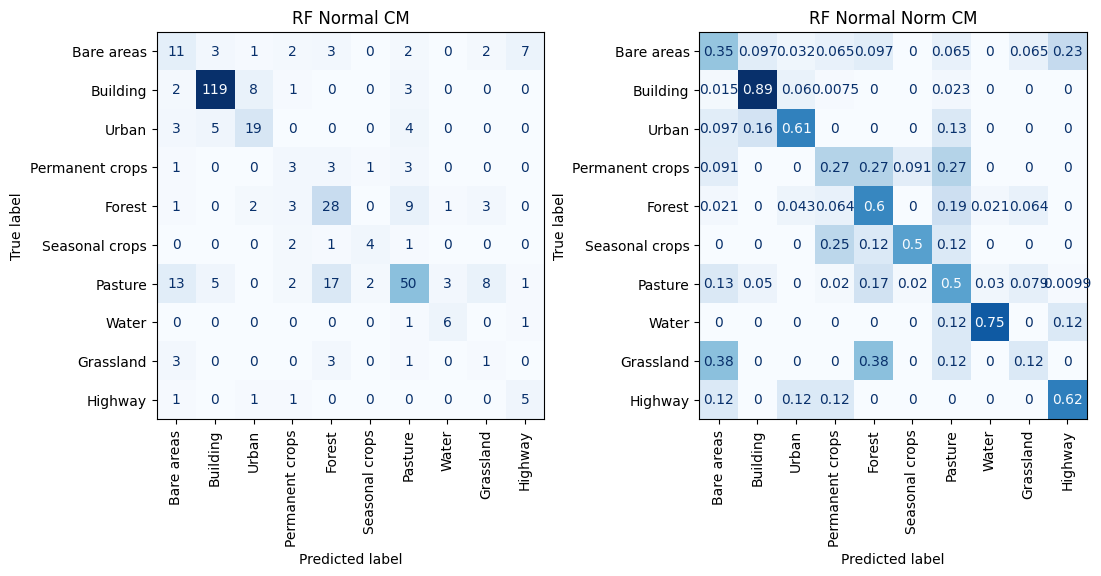

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 9, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 8, 'clf__n_estimators': 124}
Val f1: 0.4865819131845296
Train f1: 0.8462191388006822
Test f1: 0.4950


In [55]:
exp_group2.run_rf_normal()

#### Results and evaluation

For our evaluations we chose to maximize the Macro F1-score as it gives equal weight to all classes, which is important in our imbalanced dataset scenario as we want the models to perform well across all land cover classes, not just the majority ones.

The Training F1 score is 0.84 while the Test F1 score is 0.49. The model seems to overfit the training data, which is expected as our dataset is imbalanced, we will try to mitigate this in the next experiments using sampling techniques.

On the normalized confusion matrix, we can see that the model performs well on the `Building`, `Urban` classes. However, some classes are never or very little predicted such as `Permanent crops`, `Water`, `Seasonal crops`.
This may be explained by the similarity of features between these classes and other more represented classes in the dataset. For example, `Grass land` true labels are often predicted as `Pastures`, which is understandable as both classes may have similar pixel statistics.


RF SMOTE
Fitting 5 folds for each of 30 candidates, totalling 150 fits


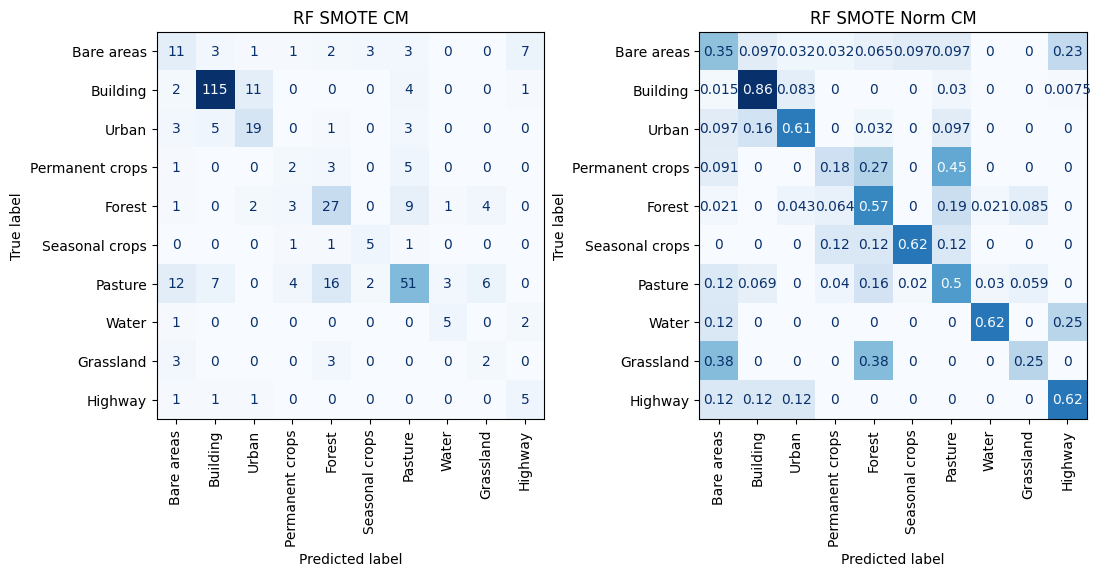

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 9, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 8, 'clf__n_estimators': 124}
Val f1: 0.47241115645547505
Train f1: 0.8588387855788078
Test f1: 0.4866


In [56]:
exp_group2.run_rf_with_smote()

To mitigate the overfitting and improve the model performance on underrepresented classes, we will tried to use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority classes in the training set. This technique can help balance the class distribution and improve the model's ability to generalize to unseen data. But as we have seen on the results, the F1-score on the test set decreased to 0.48, indicating that the model's performance worsened after applying SMOTE.

### Algorithm 2 - Support Vector Machine (SVM)

The Support Vector Machine (SVM) algorithm is a supervised machine learning model that can be used for classification tasks. It works by finding the optimal hyperplane that separates different classes in the feature space. SVMs are particularly effective in high-dimensional spaces and can handle non-linear decision boundaries using kernel functions. We used the [sklearn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) of SVM for our experiments.

We chose this algorithm because it is known for its effectiveness in handling high-dimensional data and its ability to find complex decision boundaries, which may be beneficial for our land cover classification task, it is also an algorithm that we studied in depth during our classes.


SVM Normal


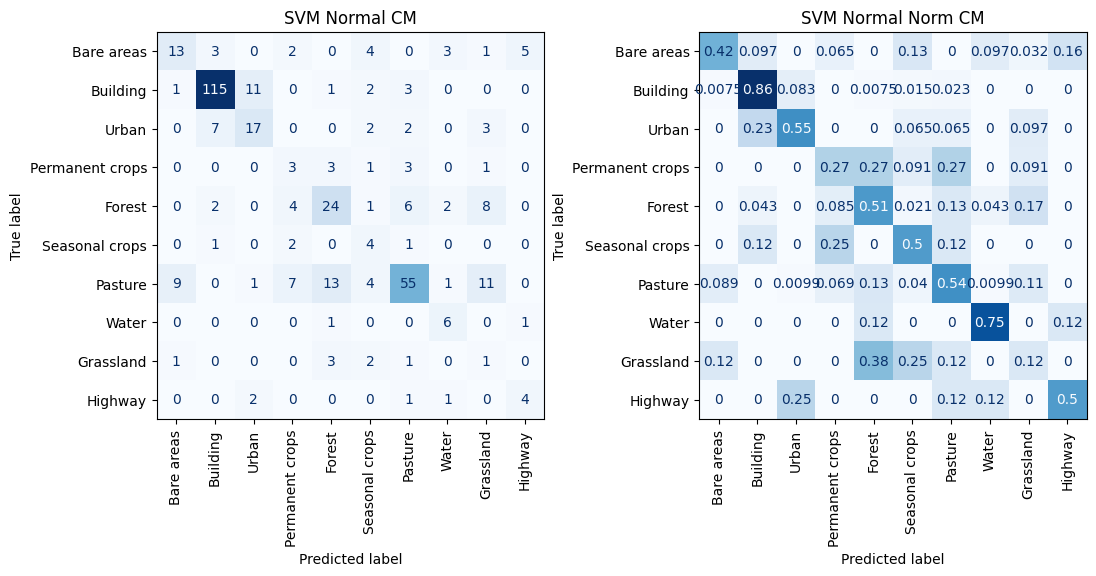

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.45803535625505587
Train f1: 0.7089026805350638
Test f1: 0.4629


In [57]:
exp_group2.run_svm_normal()

With SVM, the Training F1 score is 0.70 while the Test F1 score is 0.46. Just like with the Random Forest Classifier, the model seems to overfit the training data but not as much, for the same reasons mentioned before. We will also try to mitigate this in the next experiments using sampling techniques.


SVM SMOTE


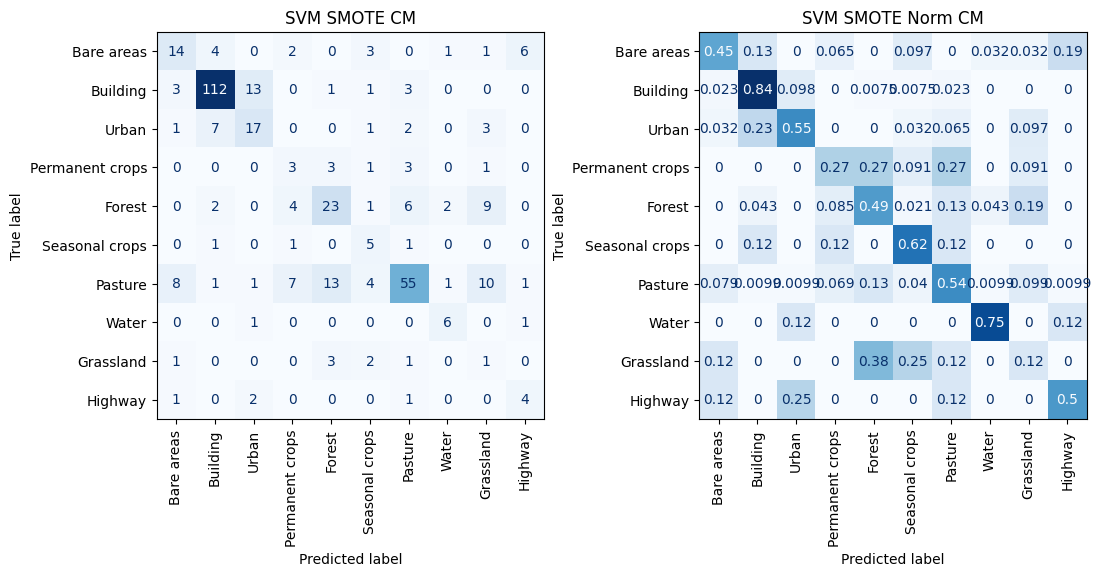

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.4701652494002081
Train f1: 0.7367968159386965
Test f1: 0.4732


In [58]:
exp_group2.run_svm_with_smote()

#### Models comparisons


RF Normal
Fitting 5 folds for each of 30 candidates, totalling 150 fits


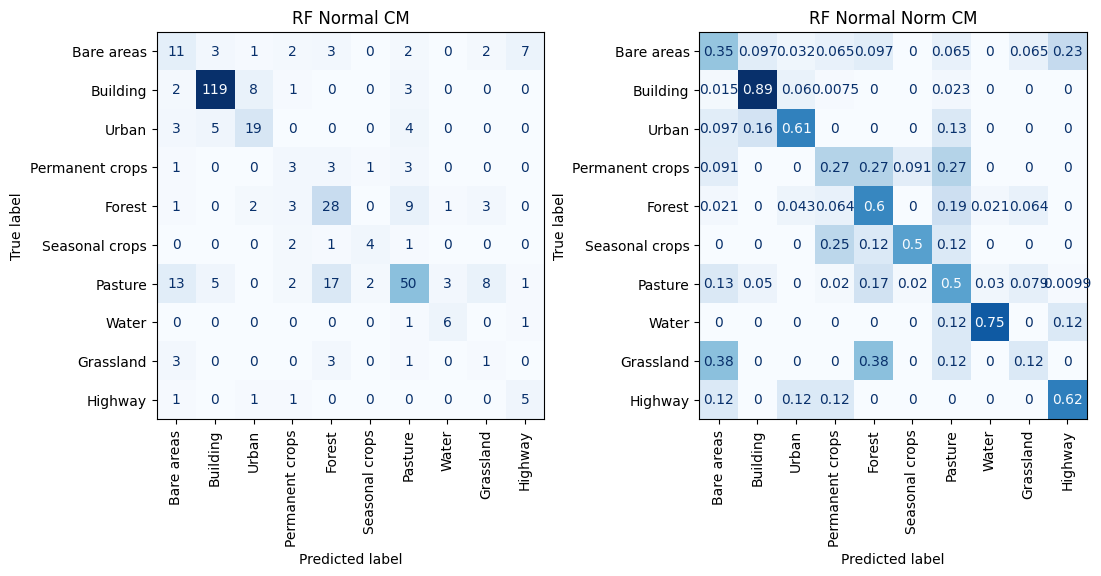

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 9, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 8, 'clf__n_estimators': 124}
Val f1: 0.4865819131845296
Train f1: 0.8462191388006822
Test f1: 0.4950

RF SMOTE
Fitting 5 folds for each of 30 candidates, totalling 150 fits


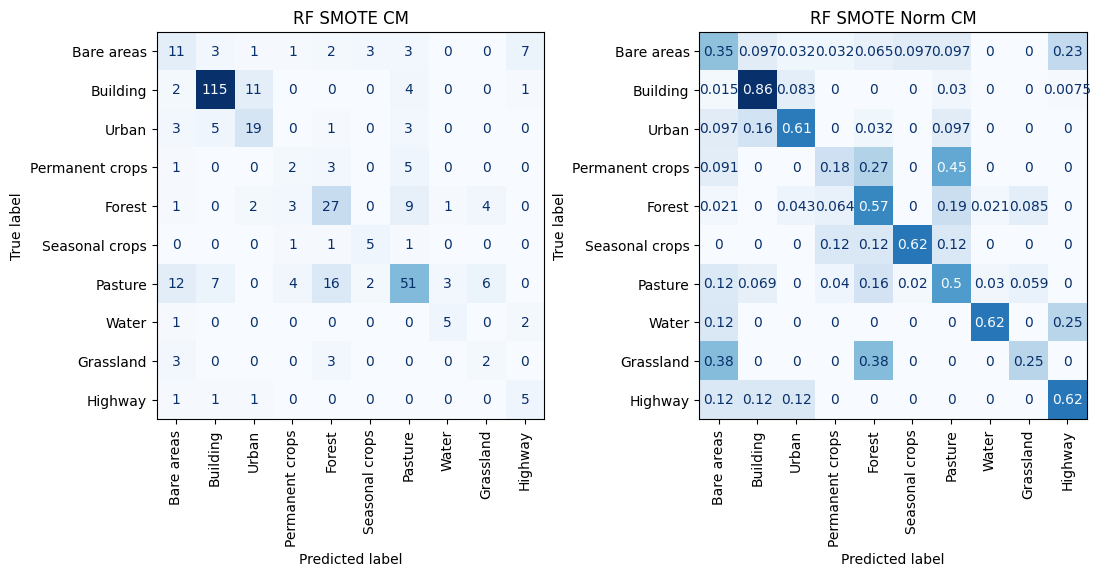

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 9, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 8, 'clf__n_estimators': 124}
Val f1: 0.47241115645547505
Train f1: 0.8588387855788078
Test f1: 0.4866

SVM Normal


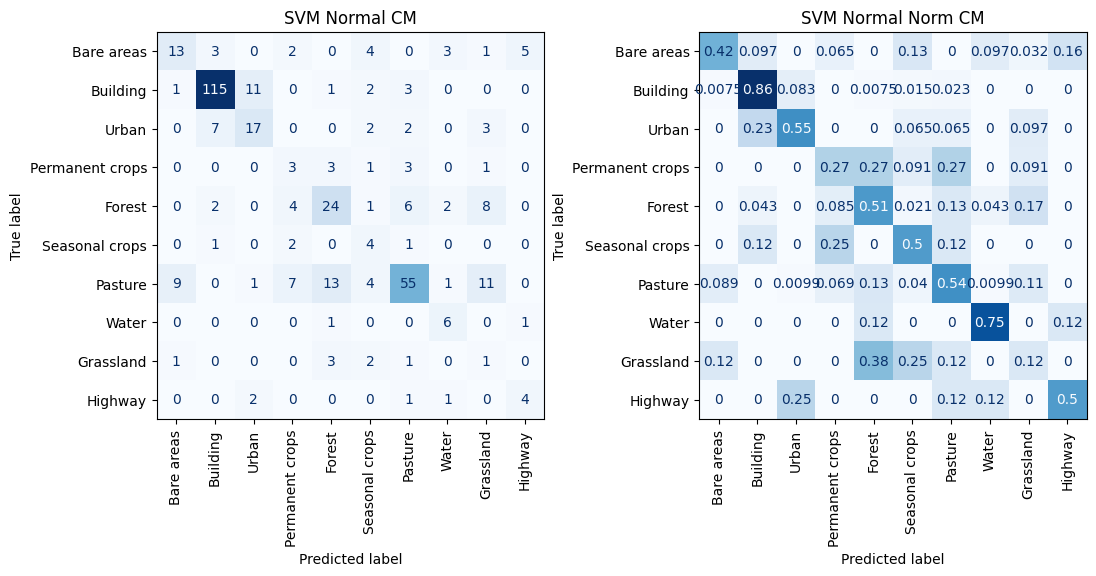

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.45803535625505587
Train f1: 0.7089026805350638
Test f1: 0.4629

SVM SMOTE


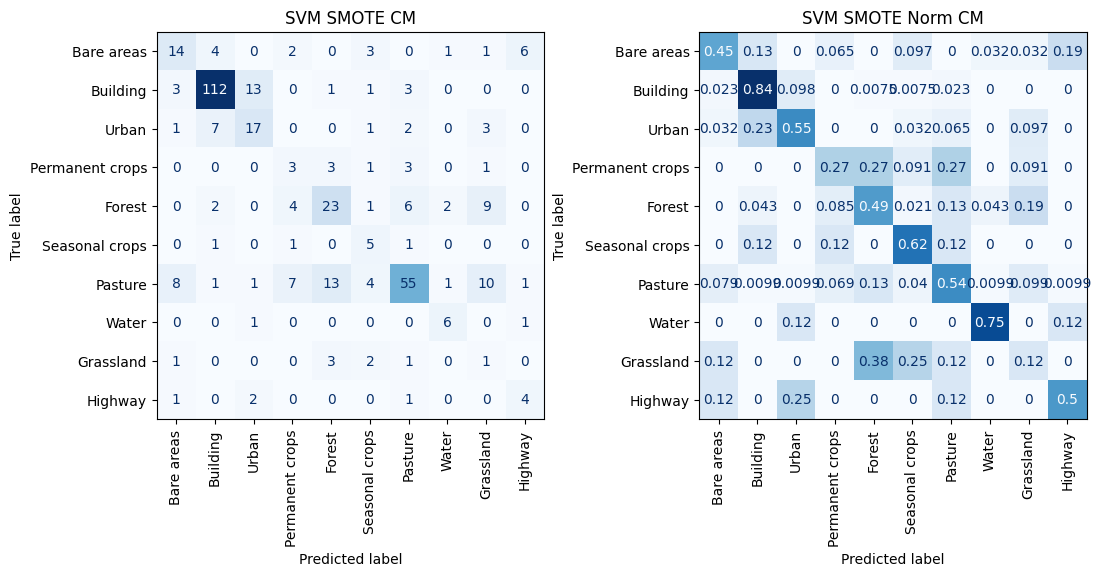

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.4701652494002081
Train f1: 0.7367968159386965
Test f1: 0.4732

Boruta
Selected: 20/22
Removed: {'eccentricity', 'solidity'}

RF SMOTE (Boruta)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


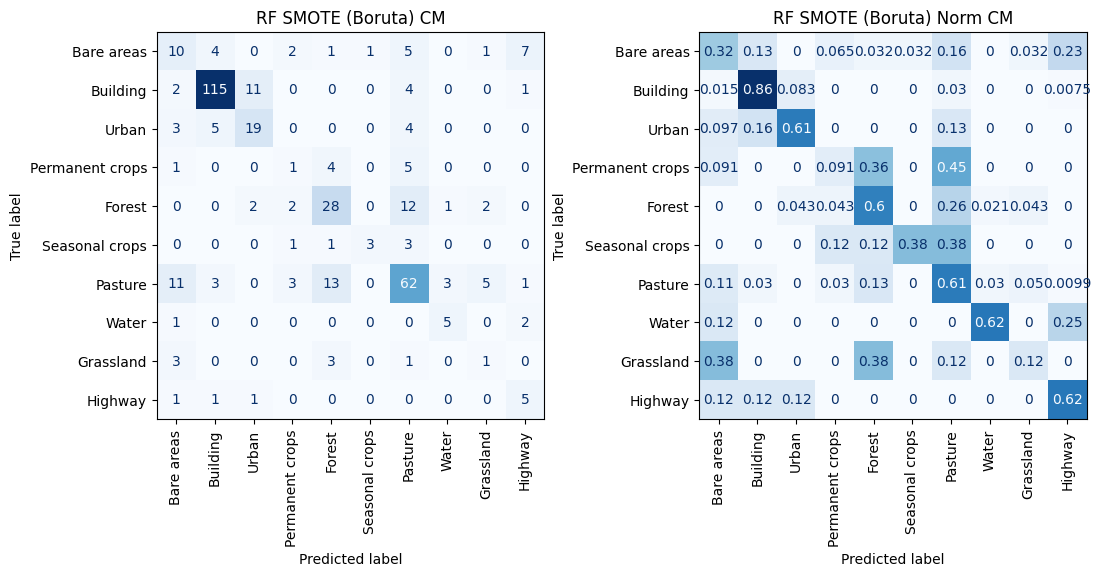

Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 20, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 13, 'clf__n_estimators': 153}
Val f1: 0.47050222284096777
Train f1: 0.8873848296679683
Test f1: 0.4722


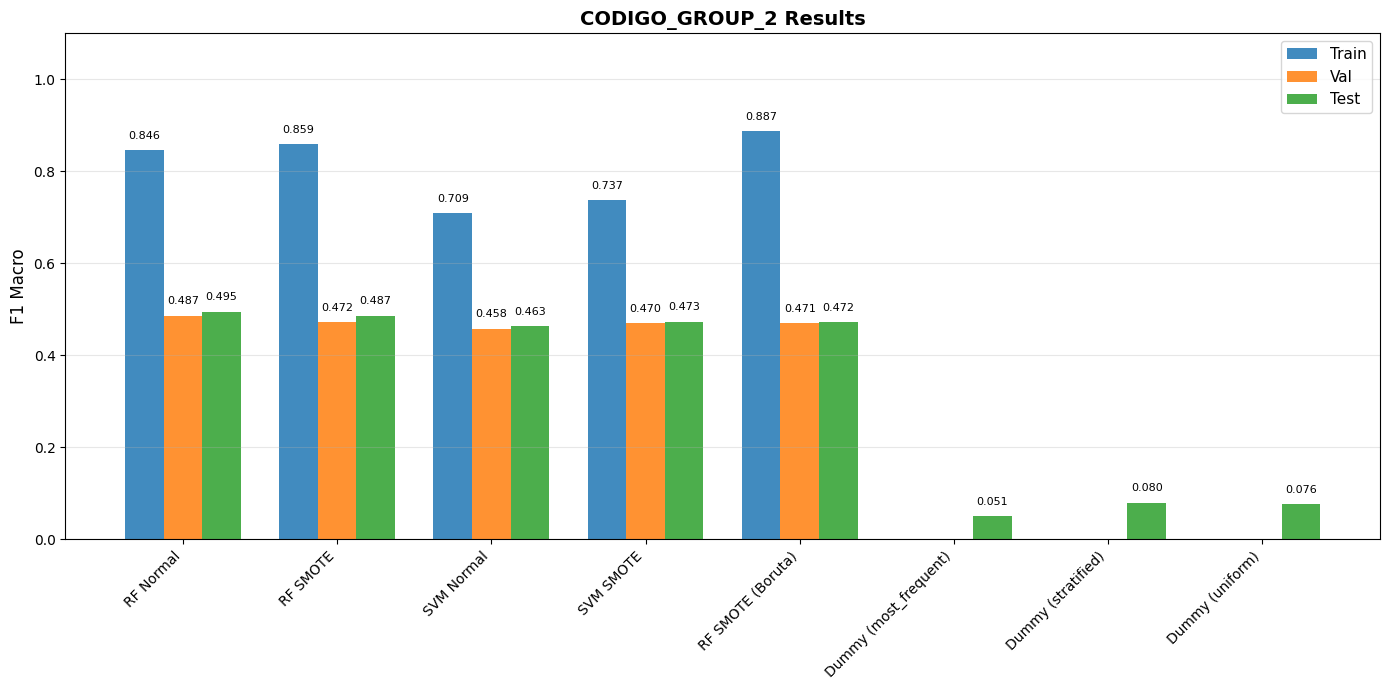

In [59]:
exp_group2.run_all_experiments(include_boruta=True)

#### Results and evaluation

On the models plot comparison, we can see that the Random Forest Classifier with Boruta feature selection and SMOTE sampling technique performs the best, achieving a Test F1 score of 0.47. This is still not very high, and the model also shows signs of overfitting, as indicated by the higher Training F1 score compared to the Test F1 score. Knowing this, we decided to perform further experiments on a reduced dataset with only 5 classes to see if the model performance improves.

### Codigo Group 1 

These experiments are ran on the dataset with 5 classes.

train distribution:
OBSERV_GROUP
Building               532
Agriculture            483
Forest                 342
Artificial Surfaces    154
Water                   32
Name: count, dtype: int64

test distribution:
OBSERV_GROUP
Building               133
Agriculture            121
Forest                  85
Artificial Surfaces     39
Water                    8
Name: count, dtype: int64

RF Normal
Fitting 5 folds for each of 30 candidates, totalling 150 fits


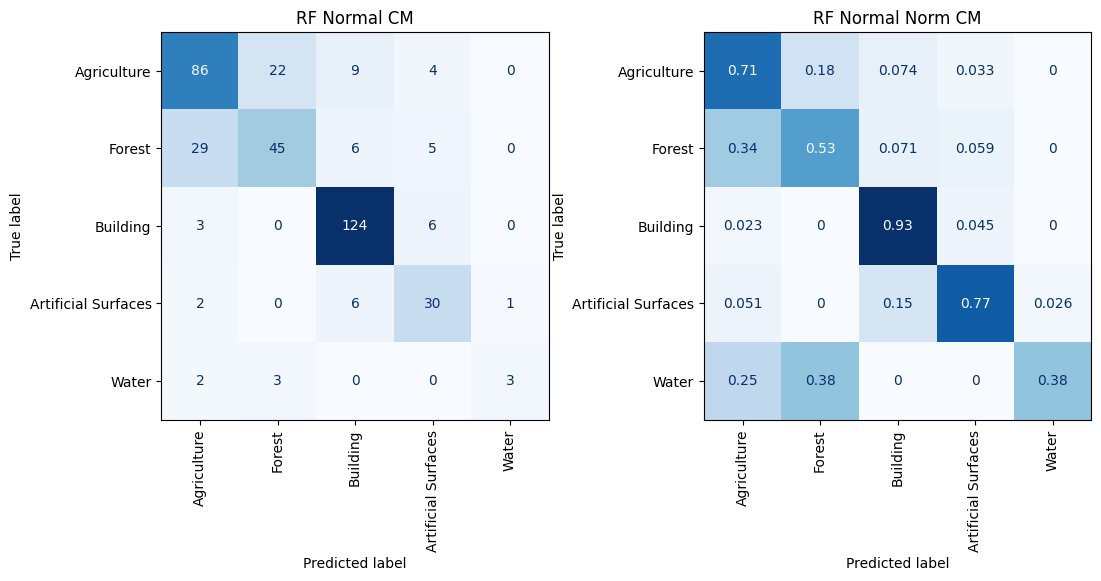

Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 20, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 6, 'clf__n_estimators': 73}
Val f1: 0.6908461639875242
Train f1: 0.9654608973038806
Test f1: 0.6790

RF SMOTE
Fitting 5 folds for each of 30 candidates, totalling 150 fits


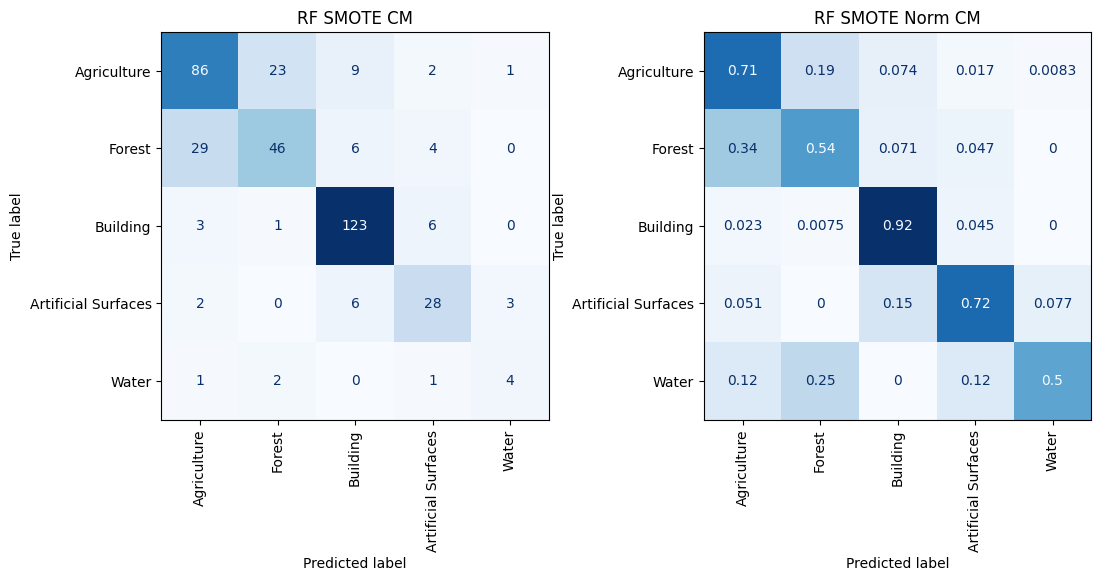

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 12, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 99}
Val f1: 0.6992633546680208
Train f1: 0.9723164828695205
Test f1: 0.6770

SVM Normal


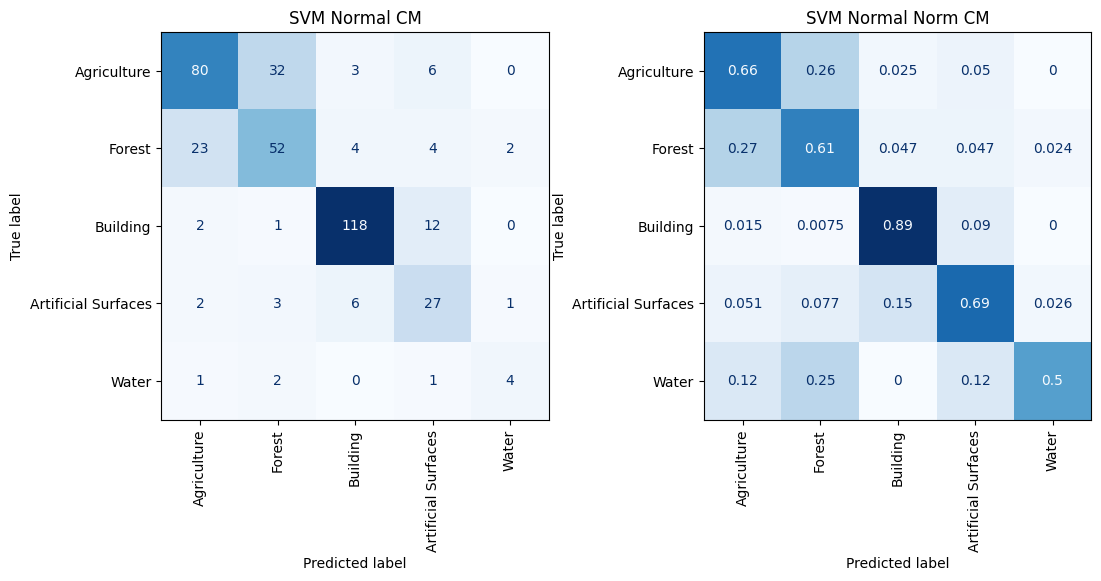

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.6670697907306264
Train f1: 0.8188491986787823
Test f1: 0.6654

SVM SMOTE


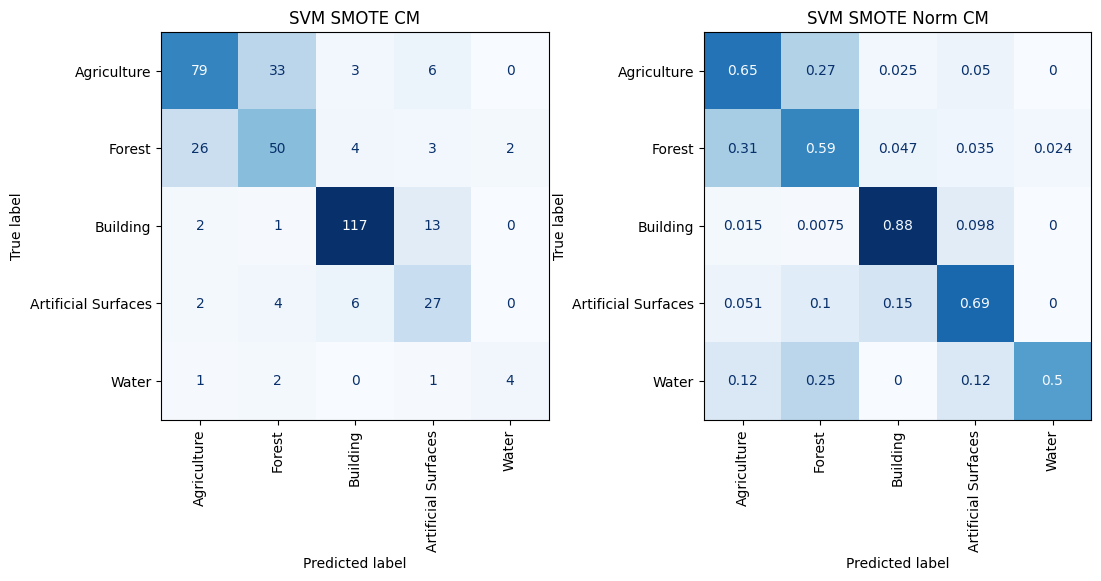

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.6568216268915987
Train f1: 0.82682765063918
Test f1: 0.6647

Boruta
Selected: 21/22
Removed: {'solidity'}

RF SMOTE (Boruta)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


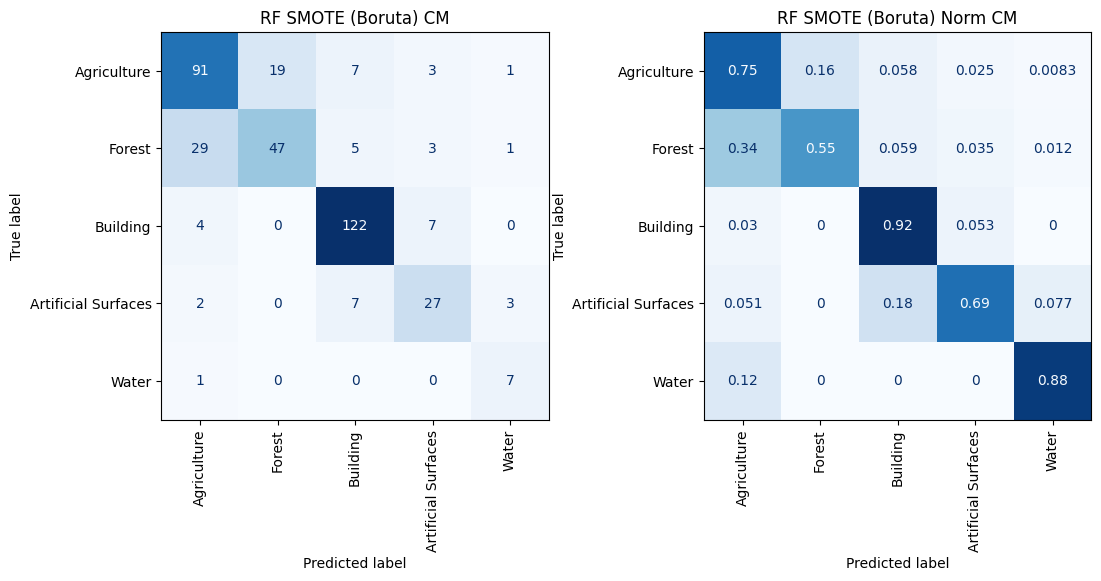

Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 20, 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 141}
Val f1: 0.6963920297835526
Train f1: 0.9776565697261681
Test f1: 0.7261


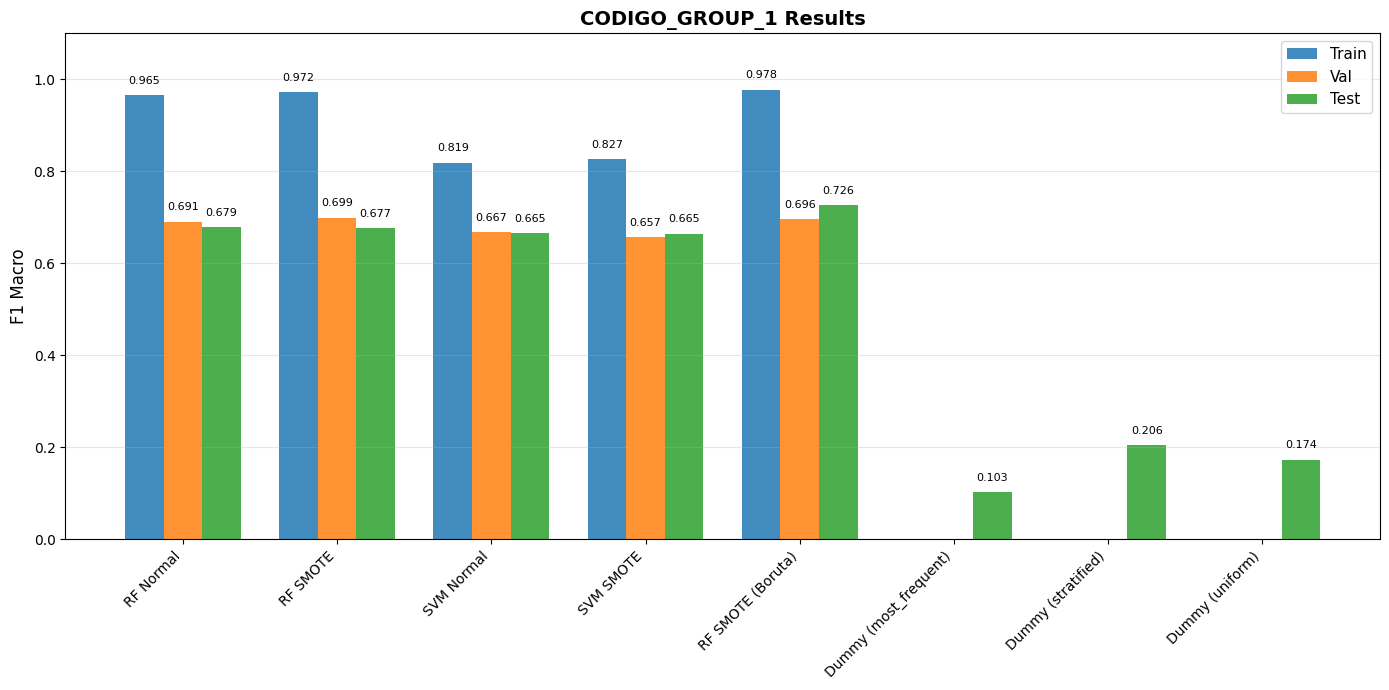

In [ ]:
exp_group1 = Runner(gdf, 'CODIGO_GROUP_1', features)
exp_group1.load_train_test_data()
exp_group1.run_all_experiments(include_boruta=True)

#### Results and evaluation on the 5-class dataset

On the models plot comparison, we can see that the Random Forest Classifier with Boruta feature selection and SMOTE sampling technique performs the best, achieving a Test F1 score of 0.72. However, this model also shows signs of overfitting, as indicated by the higher Training F1 score compared to the Test F1 score. Knowing this, we would choose plain SVM as it has a better balance between Training and Test F1 scores, indicating better generalization to unseen data.

####  Algorithm Comparison (RF vs. SVM)

| Algorithm | Core Strength (Empirical) | Core Weakness (Empirical) | Key Characteristic (Theoretical) |
| :--- | :--- | :--- | :--- |
| **Random Forest (RF)** | **Best overall score** on the full 10-class dataset (Test F1: **0.49**). | **High Overfitting** (Train F1: 0.84), leading to poor generalization. | **Ensemble/Bagging:** Handles non-linearity and provides feature importance. |
| **Support Vector Machine (SVM)** | **Better generalization** on the reduced 5-class dataset (Train : **0.82** and Test F1: **0.66**) with sampling. | **Lower score** on the full 10-class dataset (Test F1: **0.46**). | **Kernel Method:** Effective in high dimensions by finding an optimal separating hyperplane. |

## Conclusion and next steps

In this milestone, we explored two machine learning algorithms, Random Forest Classifier and Support Vector Machine (SVM), for land cover classification using our prepared dataset. We evaluated their performance using the Macro F1-score, which is suitable for our imbalanced dataset. Both algorithms showed promise, with the Random Forest Classifier performing slightly better on the full dataset, while the SVM showed better generalization on the reduced 5-class dataset.

For real-world deployment, we would recommend using the SVM with Boruta feature selection and SMOTE sampling technique for land cover classification, as it demonstrated a good balance between training and test performance, indicating better generalization to unseen data.

If we had 3 more months, we would explore additional techniques to address class imbalance, such as advanced sampling methods or cost-sensitive learning. We wouldd also experiment with other machine learning algorithms, including gradient boosting methods and deep learning approaches, as it is done with current techniques for raster data. Additionally, we would investigate feature engineering techniques to enhance the quality of our input data and potentially improve model accuracy.

The main weakness of our dataset is the lack of representation of certain land cover classes, which can lead to biased model performance. To address this, collecting more data for underrepresented classes, and exploring a wider range of features that can better capture the characteristics of these classes.